# 🖼️ -> 🖼️ Transferencia de Estilo Neuronal en PyTorch

### 🎯 Objetivo

Aplicar la técnica de transferencia de estilo neuronal (TEN) y TEN con control espacial para combinar una imagen de contenido con una imagen de estilo.

## Transferencia de estilo neuronal (Scratch)
**Imagen de contenido:**
[![Xolo Des](https://www.gaceta.unam.mx/wp-content/uploads/2021/08/xolodes.jpg)](https://www.gaceta.unam.mx/wp-content/uploads/2021/08/xolodes.jpg)

**Imagen de estilo:**
[![Mone](https://mymodernmet.com/wp/wp-content/uploads/2022/04/Henri-Edmond-Cross-puntillismo.jpeg)](https://mymodernmet.com/wp/wp-content/uploads/2022/04/Henri-Edmond-Cross-puntillismo.jpeg)



### Carga de imágenes

In [ ]:
import torch.nn.functional as F
import os
from PIL import Image
import requests
from io import BytesIO
import torchvision.transforms as transforms
import torch
from torchvision import models
import torch.optim as optim
import imageio

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_image(url, max_size=512, shape=None):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert('RGB')

    if shape:
        size = shape
    else:
        size = max_size if max(image.size) > max_size else max(image.size)

    in_transform = transforms.Compose([
        transforms.Resize(size if isinstance(size, tuple) else (size, size)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x[:3, :, :]),
        transforms.Normalize((0.485, 0.456, 0.406),
                             (0.229, 0.224, 0.225))
    ])

    image = in_transform(image).unsqueeze(0)
    return image


content_url = "https://www.gaceta.unam.mx/wp-content/uploads/2021/08/xolodes.jpg"
style_url = "https://mymodernmet.com/wp/wp-content/uploads/2022/04/Henri-Edmond-Cross-puntillismo.jpeg"

content = load_image(content_url).to(device)
style = load_image(style_url, shape=content.shape[-2:]).to(device)



### Arquitectura base (VGG19)

Usamos la red preentrenada `VGG19` de PyTorch.



In [8]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

# Congelamos los pesos
for param in vgg.parameters():
    param.requires_grad_(False)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:08<00:00, 71.1MB/s]




### Selección de capas de contenido y estilo


In [9]:
def get_features(image, model, layers=None):
    if layers is None:
        layers = {
            '0': 'conv1_1',
            '5': 'conv2_1',
            '10': 'conv3_1',
            '19': 'conv4_1',
            '21': 'conv4_2',  # contenido
            '28': 'conv5_1'
        }

    features = {}
    x = image.to(device)
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features

content_features = get_features(content, vgg)
style_features = get_features(style, vgg)


In [12]:
for i in content_features.keys():
  print(f"El bloque {i} tiene {content_features[i].shape}")

El bloque conv1_1 tiene torch.Size([1, 64, 512, 512])
El bloque conv2_1 tiene torch.Size([1, 128, 256, 256])
El bloque conv3_1 tiene torch.Size([1, 256, 128, 128])
El bloque conv4_1 tiene torch.Size([1, 512, 64, 64])
El bloque conv4_2 tiene torch.Size([1, 512, 64, 64])
El bloque conv5_1 tiene torch.Size([1, 512, 32, 32])



### Cálculo del estilo con matrices de Gram



In [59]:
def gram_matrix(tensor):
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h * w)
    gram = torch.mm(tensor, tensor.t())
    return gram


### Generación de la imagen combinada



In [15]:
target = content.clone().detach().requires_grad_(True)


Definimos pesos para cada capa de estilo:





In [16]:
style_weights = {
    'conv1_1': 1.0,
    'conv2_1': 0.75,
    'conv3_1': 0.2,
    'conv4_1': 0.2,
    'conv5_1': 0.2
}

content_weight = 1e4  # α
style_weight = 1e2    # β

✅ (Extra) Mostrar las matrices de Gram (estilo) y activaciones (contenido)

activaciones del contenido de la última capa

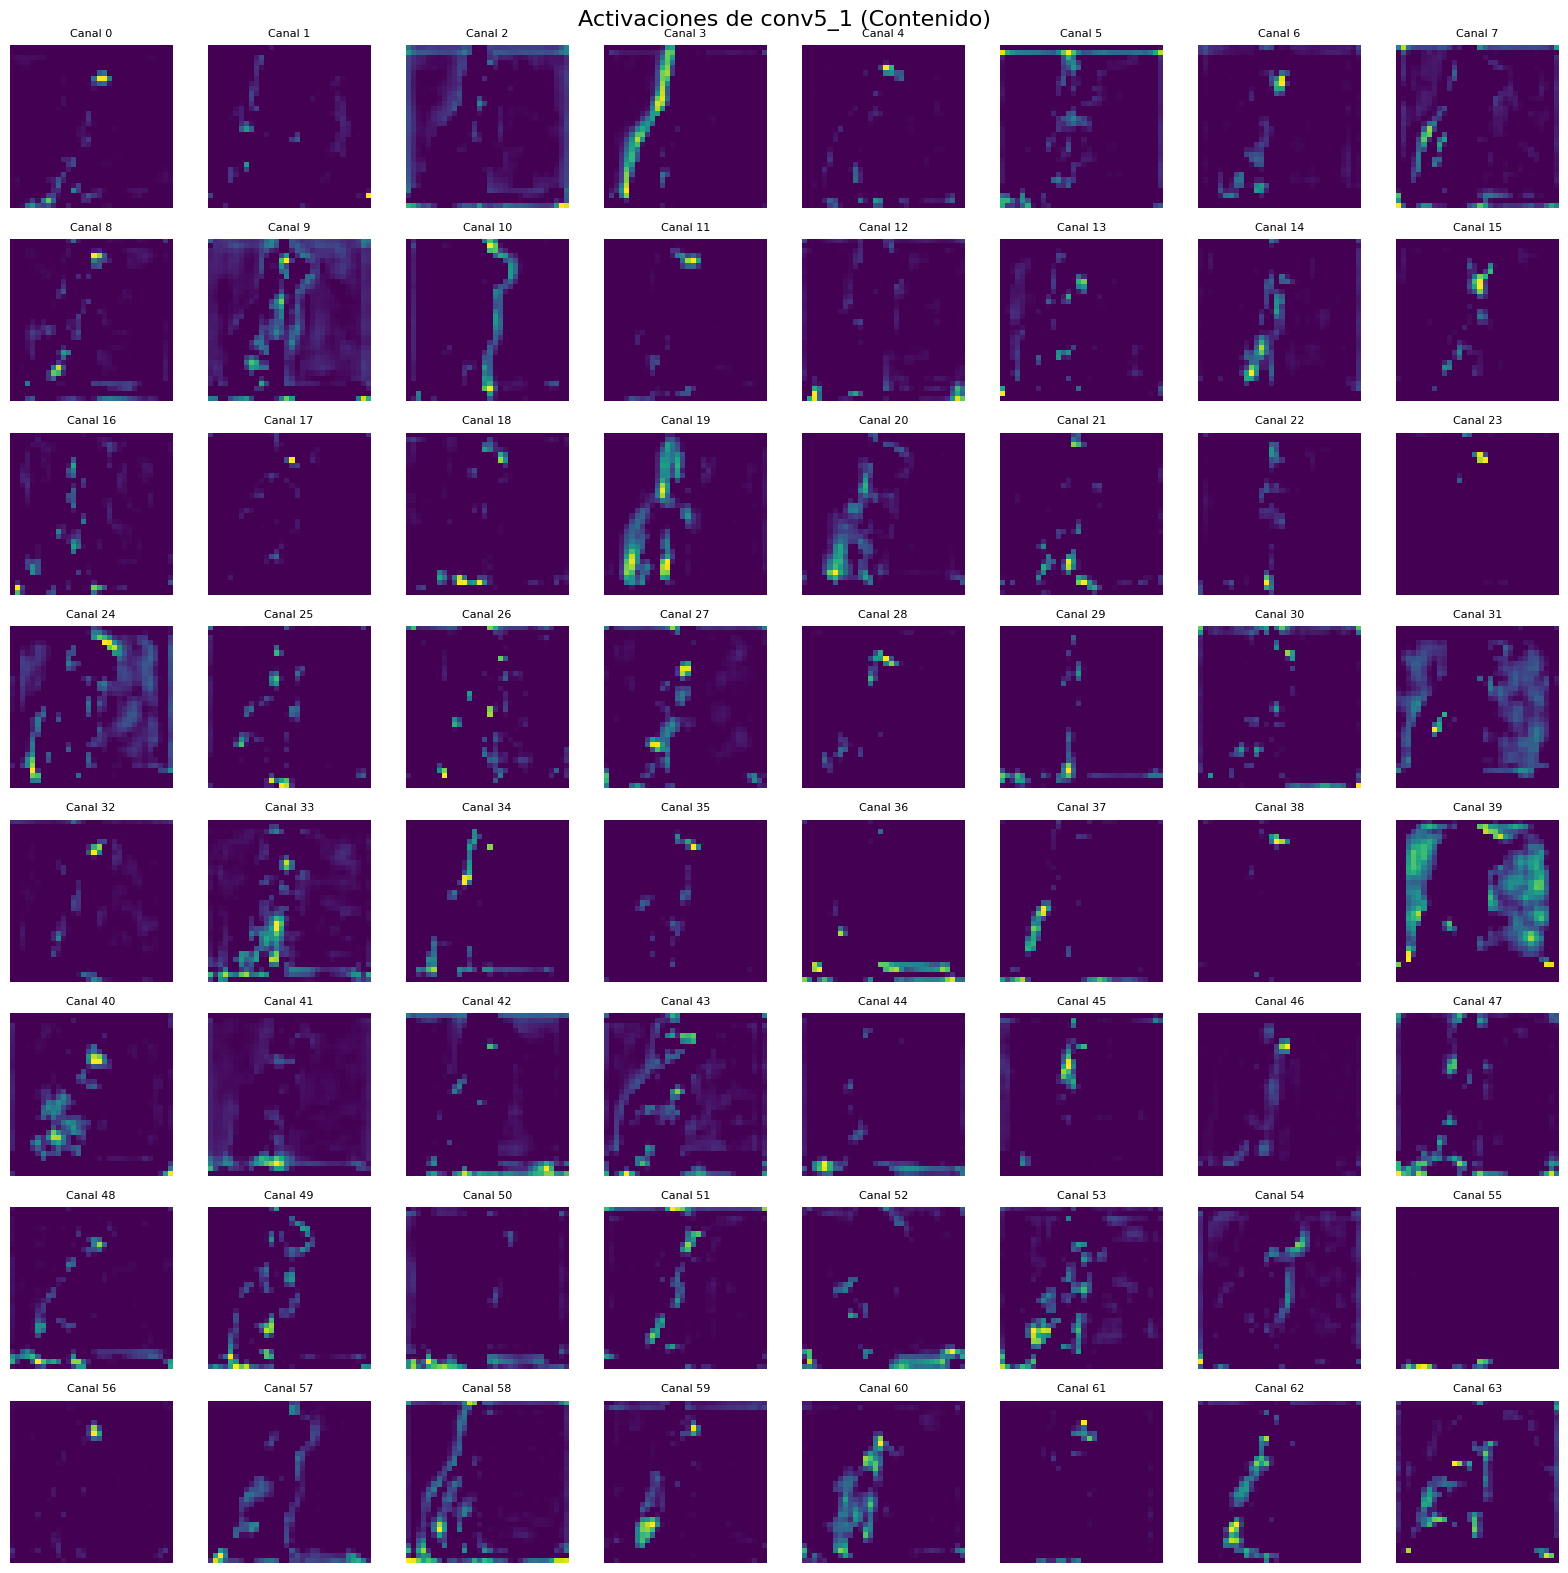

In [17]:
def plot_feature_maps(tensor, max_maps=64, cols=8, title=''):
    """
    Muestra hasta `max_maps` canales de un tensor con shape (1, C, H, W)
    """
    tensor = tensor.detach().cpu().squeeze(0)  # (C, H, W)
    channels = tensor.shape[0]
    maps_to_show = min(channels, max_maps)

    rows = (maps_to_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(title, fontsize=16)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        if i < maps_to_show:
            fmap = tensor[i]
            fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-5)  # Normaliza
            ax.imshow(fmap.numpy(), cmap='viridis')
            ax.set_title(f"Canal {i}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Asegúrate de tener esto en tu entorno antes de llamar:
# content_features = get_features(content, vgg)

# Visualiza las activaciones de conv5_1
plot_feature_maps(content_features['conv5_1'], max_maps=64, cols=8, title='Activaciones de conv5_1 (Contenido)')

Matriz Gram del estilo

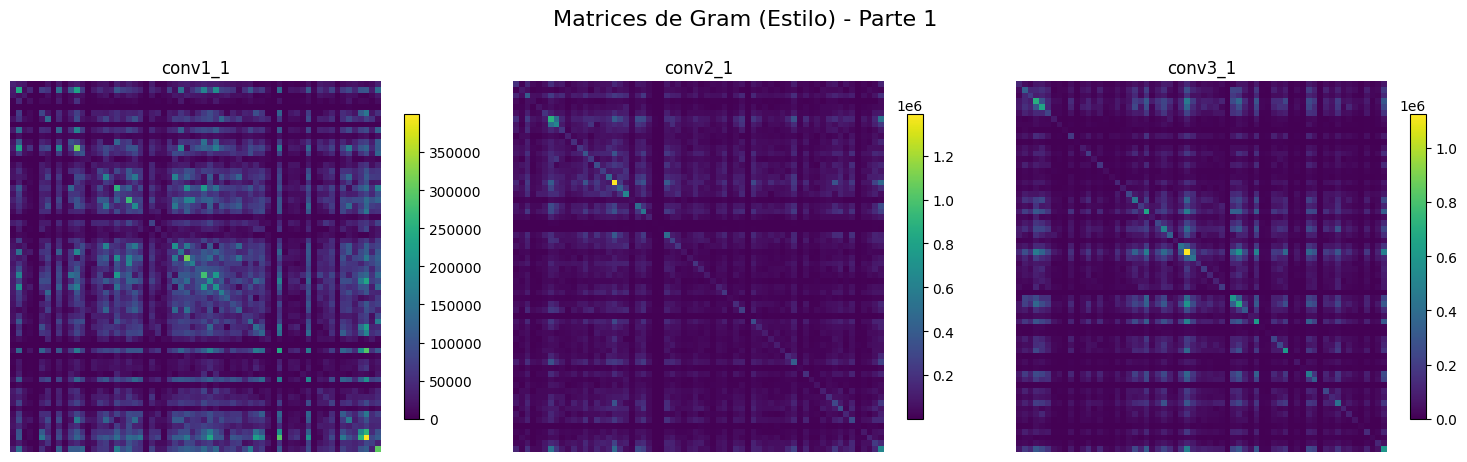

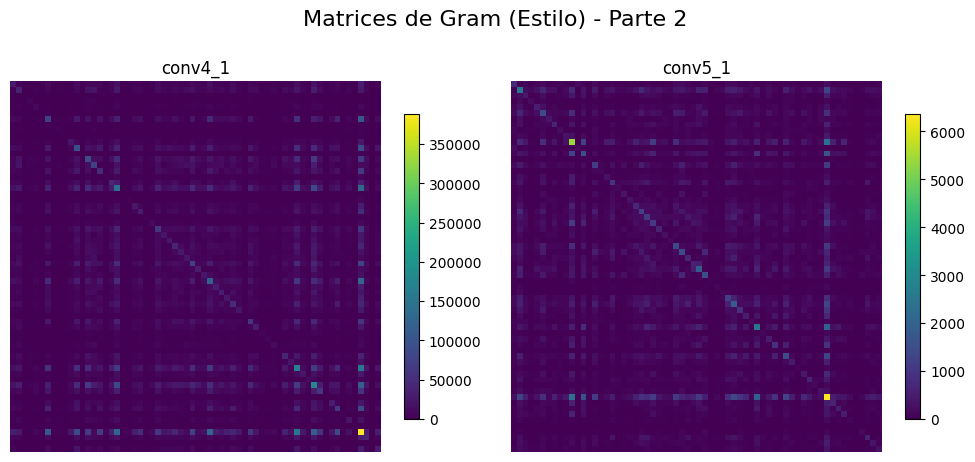

In [18]:
def show_multiple_gram_matrices(style_features, layers, title):
    fig, axes = plt.subplots(1, len(layers), figsize=(5 * len(layers), 5))
    fig.suptitle(title, fontsize=16)

    for i, layer in enumerate(layers):
        gram = gram_matrix(style_features[layer]).detach().cpu()
        if gram.shape[0] > 64:
            gram = gram[:64, :64]  # Recorta si es muy grande

        ax = axes[i]
        im = ax.imshow(gram, cmap='viridis')
        ax.set_title(layer)
        ax.axis("off")
        fig.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.show()

# Mostrar 3 primeras matrices
show_multiple_gram_matrices(style_features,
                            ['conv1_1', 'conv2_1', 'conv3_1'],
                            'Matrices de Gram (Estilo) - Parte 1')

# Mostrar 2 restantes
show_multiple_gram_matrices(style_features,
                            ['conv4_1', 'conv5_1'],
                            'Matrices de Gram (Estilo) - Parte 2')


### Ciclo de optimización



In [19]:
# Función para desnormalizar imagen
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Función para visualizar y guardar gradiente
def save_gradient_image(grad_tensor, filename):
    grad = grad_tensor.clone().detach().squeeze(0).cpu()
    grad = grad.permute(1, 2, 0)  # (H, W, 3)
    grad = grad - grad.min()
    grad = grad / grad.max()
    grad_np = (grad.numpy() * 255).astype('uint8')
    Image.fromarray(grad_np).save(filename)

# Crear carpetas
os.makedirs("results", exist_ok=True)
os.makedirs("grads", exist_ok=True)

# Inicialización
frames = []
grad_frames = []
optimizer = optim.Adam([target], lr=0.003)
steps = 2000

for i in range(steps):
    target_features = get_features(target, vgg)

    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2']) ** 2)

    style_loss = 0
    for layer in style_weights:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        style_gram = gram_matrix(style_features[layer])
        layer_loss = style_weights[layer] * torch.mean((target_gram - style_gram) ** 2)
        style_loss += layer_loss / (target_feature.shape[1] ** 2)

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()

    if i % 100 == 0:
        print(f"Step {i}, Total loss: {total_loss.item():.4f}")

        # === Guardar imagen generada ===
        image = target.clone().detach().squeeze()
        image = image.cpu()
        image = denormalize(image).clamp(0, 1)
        image = image.permute(1, 2, 0).numpy()
        img_filename = f"results/frame_{i:03d}.png"
        Image.fromarray((image * 255).astype('uint8')).save(img_filename)
        frames.append(img_filename)

        # === Guardar gradiente ===
        grad_filename = f"grads/grad_{i:03d}.png"
        save_gradient_image(target.grad, grad_filename)
        grad_frames.append(grad_filename)

    optimizer.step()

# Crear GIFs
images = [imageio.imread(f) for f in frames]
imageio.mimsave('style_transfer.gif', images, fps=5)

grad_images = [imageio.imread(f) for f in grad_frames]
imageio.mimsave('gradients.gif', grad_images, fps=5)

print("GIFs guardados como 'style_transfer.gif' y 'gradients.gif'")

Step 0, Total loss: 72650096.0000


KeyboardInterrupt: 


### 🖼️ Visualización del resultado




In [ ]:
def im_convert(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    image = image + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    image = image.clamp(0, 1)
    return image

plt.figure(figsize=(10, 10))
plt.imshow(im_convert(target).permute(1, 2, 0).clamp(0, 1).numpy())
plt.axis('off')
plt.title('Resultado de transferencia de estilo')
plt.show()

## Transferencia de estilo con Control espacial

### Transferir regiones específicas del estilo a regiones específicas del contenido usando máscaras.

### --- Funciones auxiliares ---

In [34]:
from PIL import Image
import torchvision.transforms as transforms

def load_mask_image(path, shape):
    """
    Carga una imagen de máscara y la convierte en un tensor de regiones binarias.
    Asume que cada canal es una región.
    """
    mask = Image.open(path).convert('RGB').resize(shape)
    mask = transforms.ToTensor()(mask)
    return (mask > 0.5).float()  # (3, H, W) => 3 regiones

def load_local_image(image_path, max_size=512, shape=None):
    """
    Carga una imagen desde ruta local y la transforma a tensor normalizado.
    """
    image = Image.open(image_path).convert('RGB')
    if shape:
        size = shape
    else:
        size = max_size if max(image.size) > max_size else max(image.size)
    in_transform = transforms.Compose([
        transforms.Resize(size if isinstance(size, tuple) else (size, size)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x[:3, :, :]),
        transforms.Normalize((0.485, 0.456, 0.406),
                             (0.229, 0.224, 0.225))
    ])
    image = in_transform(image).unsqueeze(0)
    return image

### --- Gram Matrix con control espacial ---


In [81]:
# Crea una máscara binaria para una región (x_ini, x_fin, y_ini, y_fin)
def create_region_mask(H, W, region):
    x_ini, x_fin, y_ini, y_fin = region
    mask = torch.zeros((1, H, W))
    mask[:, y_ini:y_fin, x_ini:x_fin] = 1.0
    return mask

# Cálculo de matriz de Gram con máscara
def masked_gram(x, masks, norm='square_sum'):
    """
    x: tensor (C, H, W)
    masks: tensor (1, H, W) o (R, H, W)
    norm: 'square_sum' o 'none'
    """
    if x.ndim == 4 and x.shape[0] == 1:
        x = x.squeeze(0)  # Convertir (1, C, H, W) → (C, H, W)
    C, H, W = x.shape

    if masks.ndim == 3 and masks.shape[0] == 1:
        R = 1
    elif masks.ndim == 3:
        R = masks.shape[0]
    else:
        raise ValueError("La máscara debe tener forma (1, H, W) o (R, H, W)")

    # Redimensionar las máscaras a tamaño del feature map
    masks_resized = F.interpolate(masks.unsqueeze(0), size=(H, W), mode="bilinear", align_corners=False)
    masks_resized = masks_resized.squeeze(0)  # (R, H, W)

    results = []

    for r in range(R):
        mask = masks_resized[r].unsqueeze(0)  # (1, H, W)
        x_masked = x * mask  # Broadcasting: (C, H, W) * (1, H, W)
        x_masked_flat = x_masked.view(C, -1)  # (C, H*W)
        gram = x_masked_flat @ x_masked_flat.T  # (C, C)

        if norm == 'square_sum':
            gram = gram / (mask.sum() ** 2 + 1e-8)

        results.append(gram)

    return results  # lista de (C, C)

### --- obtener imágenes ---

In [82]:
content_path = "/content/ISIC_0024313.jpg"
style_path = "/content/ISIC_0024313_segmentation.jpg"
content_mask_path = "/content/ISIC_0024351.jpg"
style_mask_path = "/content/ISIC_0024351_segmentation.jpg"

content = load_local_image(content_path).to(device)
style = load_local_image(style_path, shape=content.shape[-2:]).to(device)

### Cargar las máscaras e imagenes


In [83]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

In [84]:
guide_mask_content = load_mask_image(content_mask_path, content.shape[-2:])  # (3, H, W)
guide_mask_style = load_mask_image(style_mask_path, style.shape[-2:])  # (3, H, W)

### Gram vainilla vs control espacial

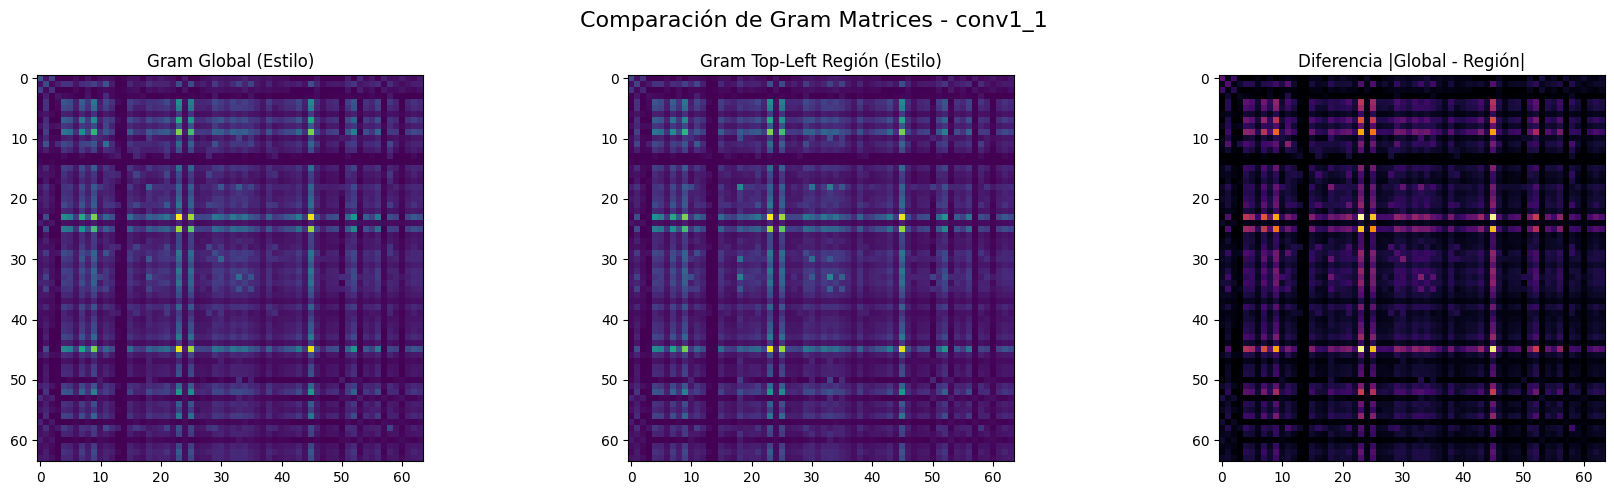

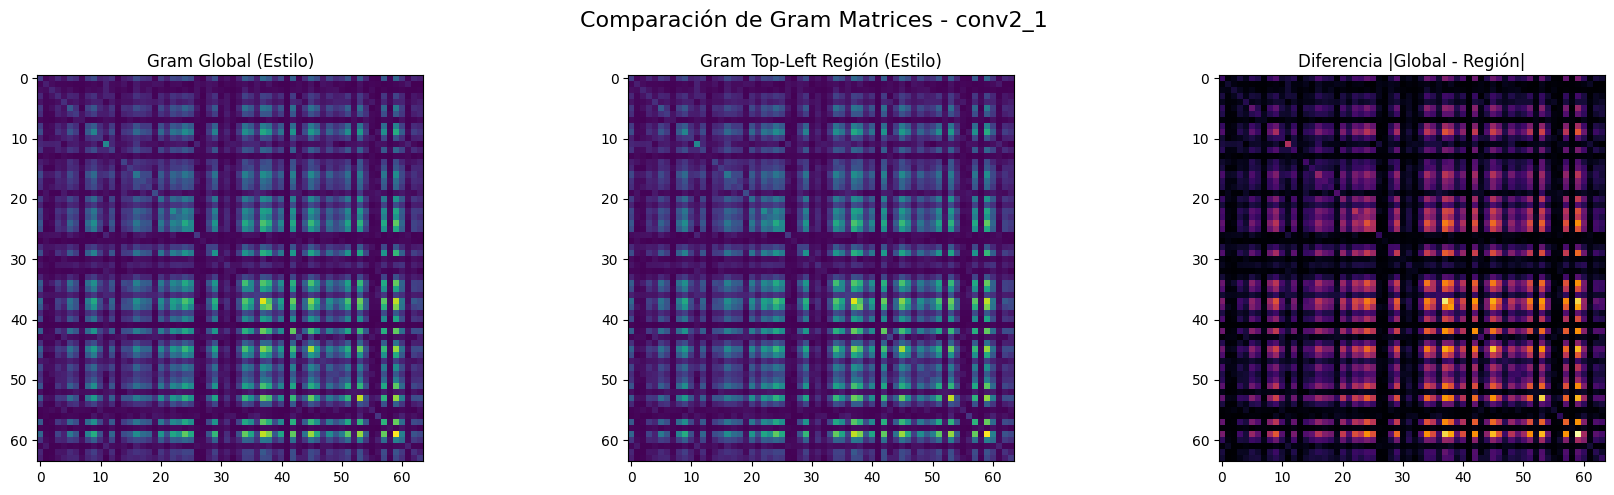

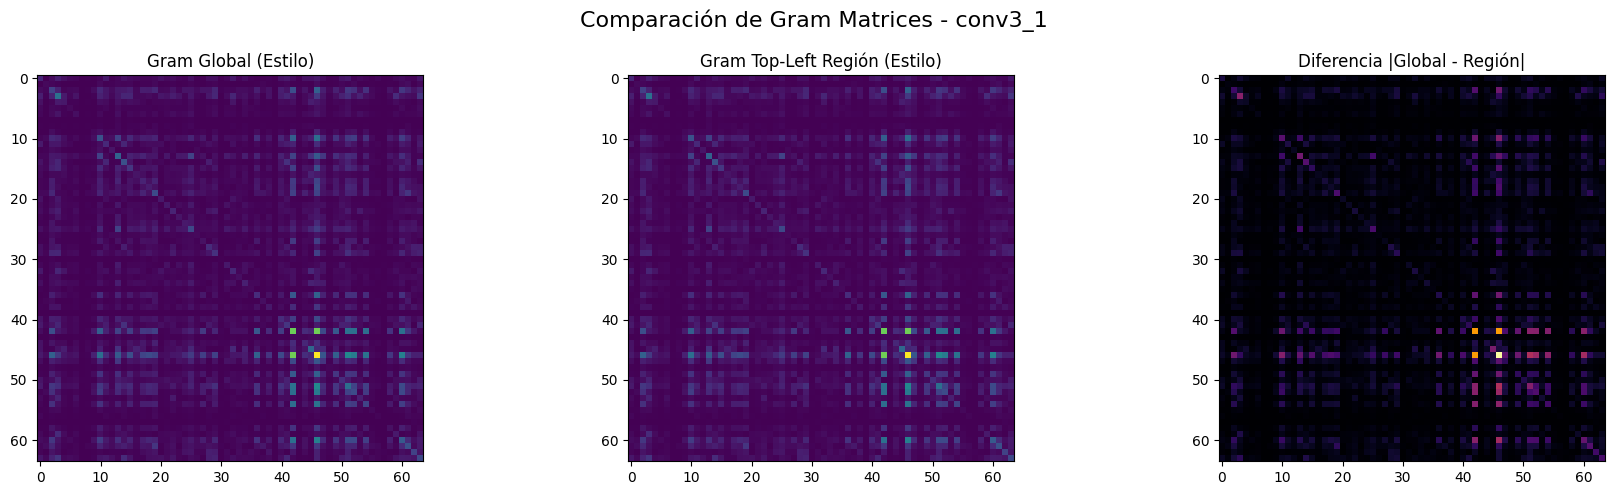

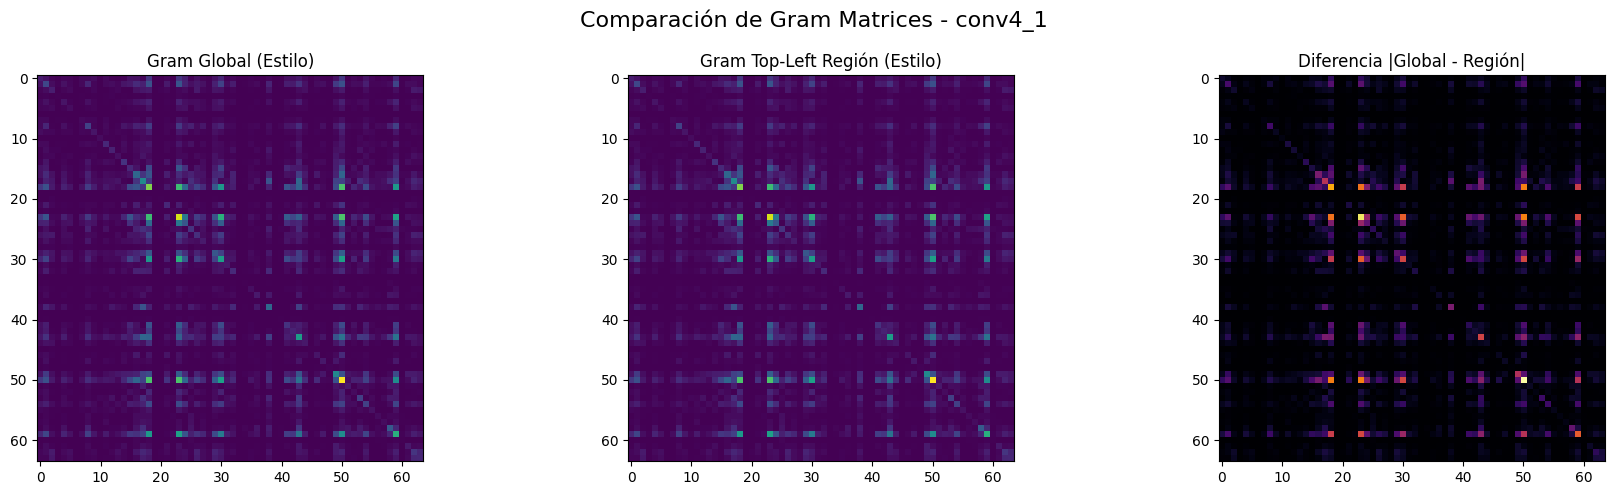

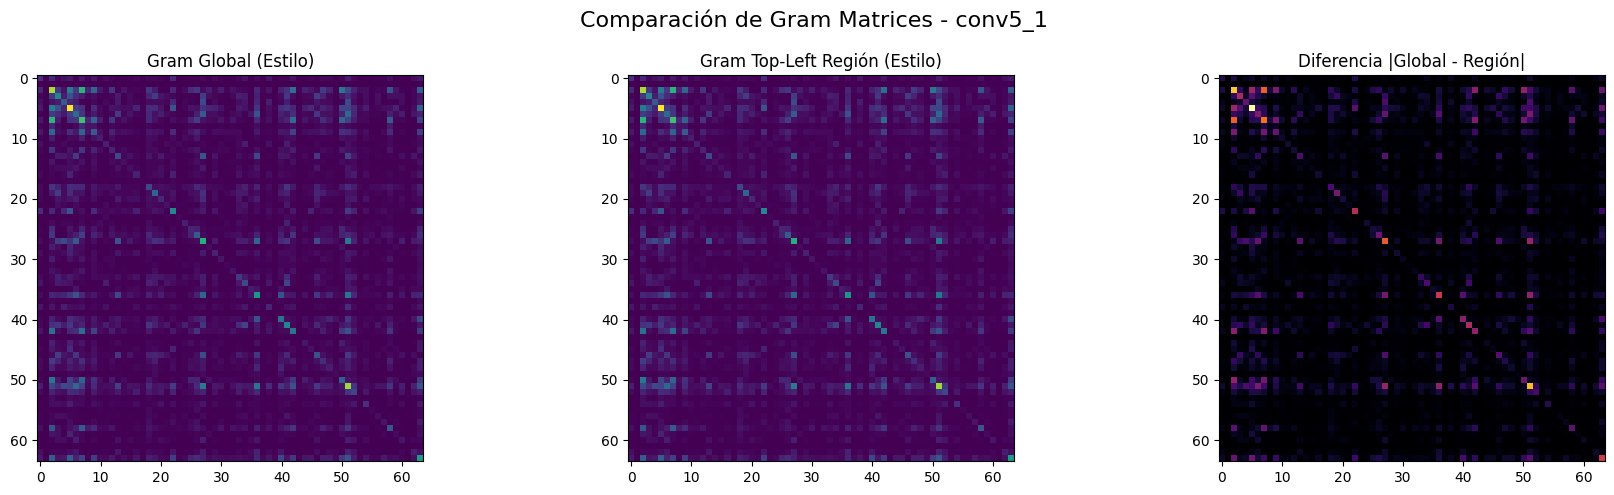

In [85]:
# Región: top-left cuadrante
region = (0, content.shape[-1]//2, 0, content.shape[-2]//2)  # (x_ini, x_fin, y_ini, y_fin)

for layer in ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']:
    # Matriz de Gram global del estilo
    gram_style_full = gram_matrix(style_features[layer]).detach()

    # Crear máscara para la región top-left
    feature_map = style_features[layer]
    _, _, H, W = feature_map.shape
    mask = create_region_mask(H, W, region)

    # Obtener matriz de Gram para la región (extraer la primera si es lista)
    gram_style_region = masked_gram(style_features[layer], mask)[0].detach()

    # Mostrar comparación visual de matrices de Gram
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].imshow(gram_style_full[:64, :64].cpu(), cmap='viridis')
    axs[0].set_title('Gram Global (Estilo)')

    axs[1].imshow(gram_style_region[:64, :64].cpu(), cmap='viridis')
    axs[1].set_title('Gram Top-Left Región (Estilo)')

    # Diferencia entre matrices
    diff = (gram_style_full - gram_style_region).abs()
    axs[2].imshow(diff[:64, :64].cpu(), cmap='inferno')
    axs[2].set_title('Diferencia |Global - Región|')

    plt.suptitle(f'Comparación de Gram Matrices - {layer}', fontsize=16)
    plt.tight_layout()
    plt.show()

### Inicializar imagen objetivo

In [87]:
target = content.clone().detach().requires_grad_(True)

### Definir optimizador y parámetros

In [88]:
optimizer = torch.optim.Adam([target], lr=0.003)
steps = 50
layer_name = 'conv4_1'

### Ciclo de optimización con control espacial


In [ ]:
for i in range(steps):
    target_features = get_features(target, vgg)
    target_act = target_features[layer_name]  # (1, C, H, W)

    content_loss = F.mse_loss(target_features['conv4_2'], get_features(content, vgg)['conv4_2'])

    # Estilo por regiones
    target_grams = masked_gram(target_act, guide_mask_content)
    style_grams = masked_gram(get_features(style, vgg)[layer_name], guide_mask_style)

    style_loss = 0
    for tg, sg in zip(target_grams, style_grams):
        style_loss += F.mse_loss(tg, sg)

    total_loss = 1e4 * content_loss + 1e2 * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 5 == 0:
        print(f"Paso {i}, Pérdida total: {total_loss.item():.4f}")




Paso 0, Pérdida total: 0.0005
Paso 5, Pérdida total: 164.8555
Paso 10, Pérdida total: 76.6965
Paso 15, Pérdida total: 42.1660
Paso 20, Pérdida total: 25.1181
Paso 25, Pérdida total: 16.1056
Paso 30, Pérdida total: 10.6548


### Visualizar resultado

In [ ]:
import matplotlib.pyplot as plt

def im_convert(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    image = image + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    image = image.clamp(0, 1)
    return image

plt.figure(figsize=(10, 10))
plt.imshow(im_convert(target).permute(1, 2, 0).numpy())
plt.axis('off')
plt.title('Resultado con control espacial de estilo')
plt.show()